# Biological Explanation Evaluation — LLM-as-Judge

Evaluates the quality of biological explanations generated by the Mistral-7B-Instruct RAG pipeline.

### Approach
1. Parse each numbered section in `biological_explanation` as an independent statement
2. Feed **all statements together** (in one prompt) plus the retrieved evidence to a **configurable judge LLM**
3. The judge assigns one score per statement using a **5-level rubric**:

| Score | AMP meaning | non-AMP meaning |
|-------|-------------|-----------------|
| **1.0** | Biologically plausible + directly supported by retrieved evidence | Identified missing feature is a known, established AMP requirement |
| **0.8** | Biologically plausible + partially supported by evidence — reasonable inference | Broadly correct but may oversimplify or generalise |
| **0.5** | Biologically plausible but speculative — not directly grounded in evidence | Vague or not a well-established biological principle |
| **0.3** | Biologically questionable — partially incorrect or unsupported generalisation | Contains inaccuracies about AMP/non-AMP biology |
| **0.0** | Not biologically plausible and not grounded in the retrieved evidence | Contradicts established biology or the retrieved evidence |

4. Per-explanation score = **mean of all statement scores** (0.0 values are included, not filtered)

### Configurable Judge Backends
| Backend | Model | Notes |
|---------|-------|-------|
| `ollama` | `qwen2.5:7b` (default) | **Recommended** — best structured JSON, fewer parse errors |
| `ollama` | `llama3.1:8b` | Good baseline, already installed |
| `ollama` | `gemma2:9b` | Good reasoning, larger (~7 GB RAM) |
| `anthropic` | `claude-haiku-4-5` | Best quality / cost ratio |
| `anthropic` | `claude-sonnet-4-6` | Highest accuracy |

> **Note**: `mistral:7b-instruct` is excluded as judge — it generated the explanations (conflict of interest).


## 1. Configuration

Change these parameters before running.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit these before running
# ═══════════════════════════════════════════════════════════════════════════

# Judge LLM backend: "ollama" | "anthropic"
JUDGE_BACKEND  = "ollama"

# Model name — must match backend:
#   ollama   : "qwen2.5:7b" (recommended) | "llama3.1:8b" | "gemma2:9b"
#   anthropic: "claude-haiku-4-5" (cost-effective) | "claude-sonnet-4-6" (highest accuracy)
JUDGE_MODEL    = "qwen2.5:7b"

# Sampling temperature (0 = deterministic, reproducible)
TEMPERATURE    = 0

# ── Dataset selection ──────────────────────────────────────────────────────
# EVAL_DATASET = "both"    → evaluate AMP and non-AMP rows (full run)
# EVAL_DATASET = "AMP"     → evaluate only AMP rows; keep existing non-AMP from OUTPUT_CSV
# EVAL_DATASET = "non-AMP" → evaluate only non-AMP rows; keep existing AMP from OUTPUT_CSV
EVAL_DATASET = "non-AMP"

# ── Row selection (applies within the selected dataset) ────────────────────
# SAMPLE_PCT = 100.0 → all rows in EVAL_DATASET
# SAMPLE_PCT = 10.0  → 10% of rows in EVAL_DATASET
SAMPLE_PCT = 10.0

# Fixed number of rows — used only when SAMPLE_PCT is None
NUM_ROWS = None

# Save a checkpoint CSV every N rows
CHECKPOINT_EVERY = 50

# ── Re-run control ─────────────────────────────────────────────────────────
# FORCE_RERUN = True  → resume from checkpoint (safe default)
# FORCE_RERUN = True   → ignore checkpoint, re-evaluate all rows from scratch
FORCE_RERUN = True

# Ollama server URL
OLLAMA_BASE_URL = "http://localhost:11434"

# Output paths
import os
from pathlib import Path

PROJECT_ROOT   = Path(os.getcwd()).parent
RESULTS_DIR    = PROJECT_ROOT / "results"
PLOTS_DIR      = PROJECT_ROOT / "plots" / "evaluation" / "bio_eval"
AMP_CSV        = RESULTS_DIR / "amp_rag_results.csv"
NON_AMP_CSV    = RESULTS_DIR / "non_amp_rag_results.csv"
CHECKPOINT_CSV = RESULTS_DIR / "bio_eval_checkpoint.csv"
OUTPUT_CSV     = RESULTS_DIR / "bio_eval_results.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Judge backend    : {JUDGE_BACKEND}")
print(f"Judge model      : {JUDGE_MODEL}")
print(f"Temperature      : {TEMPERATURE}")
print(f"Eval dataset     : {EVAL_DATASET}")
if SAMPLE_PCT is not None:
    print(f"Sample %         : {SAMPLE_PCT}%  (within {EVAL_DATASET} rows)")
else:
    print(f"Sample %         : None  → using NUM_ROWS={NUM_ROWS} (or ALL if None)")
print(f"Checkpoint every : {CHECKPOINT_EVERY}")
print(f"Force rerun      : {FORCE_RERUN}  {'← checkpoint will be ignored' if FORCE_RERUN else '← resumes from checkpoint if it exists'}")
print(f"Output CSV       : {OUTPUT_CSV}")
if EVAL_DATASET != "both" and OUTPUT_CSV.exists():
    import pandas as pd
    df_ex = pd.read_csv(OUTPUT_CSV)
    kept = df_ex[df_ex["dataset"] != EVAL_DATASET]
    print(f"\n→ {len(kept)} existing '{kept['dataset'].iloc[0] if len(kept) else '?'}' rows will be kept from {OUTPUT_CSV.name}")
    print(f"→ Only '{EVAL_DATASET}' rows will be re-evaluated")


Judge backend    : ollama
Judge model      : qwen2.5:7b
Temperature      : 0
Eval dataset     : non-AMP
Sample %         : 10.0%  (within non-AMP rows)
Checkpoint every : 50
Force rerun      : True  ← checkpoint will be ignored
Output CSV       : /Users/deepugeorgejacob/Projects/amp-rag/results/bio_eval_results.csv

→ 358 existing 'AMP' rows will be kept from bio_eval_results.csv
→ Only 'non-AMP' rows will be re-evaluated


## 2. Imports & Environment

In [2]:
!pip install python-dotenv -q

You should consider upgrading via the '/Users/deepugeorgejacob/Projects/amp-rag/.venv/bin/python3 -m pip install --upgrade pip' command.


In [3]:
import os, json, re, time, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
from tqdm.auto import tqdm

try:
    from dotenv import load_dotenv
    loaded = load_dotenv(PROJECT_ROOT / ".env")
    if not loaded:
        print("Warning: .env file not found or empty")
except ImportError:
    print("Warning: python-dotenv not installed — run: !pip install python-dotenv -q")

warnings.filterwarnings("ignore")

# ── Global plot style (all text bold) ─────────────────────────────────────────
plt.rcParams.update({
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "axes.titlesize":    14,
    "axes.labelsize":    12,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "figure.dpi":        120,
    "figure.facecolor":  "white",
})
sns.set_theme(style="whitegrid")

print("Imports OK")
print(f"ANTHROPIC_API_KEY set: {'Yes' if os.getenv('ANTHROPIC_API_KEY') else 'No (needed only for anthropic backend)'}")


Imports OK
ANTHROPIC_API_KEY set: Yes


/Users/deepugeorgejacob/Projects/amp-rag/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 3. Backend Setup

### Anthropic backend only
If `JUDGE_BACKEND = "anthropic"`, uncomment and run the cell below first:


In [4]:
# Uncomment if using Anthropic backend
!pip install anthropic -q


You should consider upgrading via the '/Users/deepugeorgejacob/Projects/amp-rag/.venv/bin/python3 -m pip install --upgrade pip' command.


In [5]:
# ── Ollama health check (runs only if JUDGE_BACKEND == "ollama") ─────────────
if JUDGE_BACKEND == "ollama":
    try:
        r = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5)
        r.raise_for_status()
        available = [m["name"] for m in r.json().get("models", [])]
        print(f"Ollama server  : OK")
        print(f"Models available: {available}")
        if JUDGE_MODEL in available:
            print(f"Judge model    : {JUDGE_MODEL} — ready")
        else:
            print(f"Judge model    : {JUDGE_MODEL} — NOT FOUND")
            print(f"  Run this to download it:")
            print(f"  !ollama pull {JUDGE_MODEL}")
    except requests.exceptions.ConnectionError:
        print("Ollama not reachable — start with: ollama serve")
    except Exception as e:
        print(f"Health check error: {e}")
else:
    api_key = os.getenv("ANTHROPIC_API_KEY", "")
    if api_key and api_key != "your_anthropic_api_key_here":
        print(f"Anthropic API key: set ({api_key[:8]}...)")
    else:
        print("Anthropic API key: MISSING — set ANTHROPIC_API_KEY in .env")


Ollama server  : OK
Models available: ['qwen2.5:7b', 'mistral:7b-instruct']
Judge model    : qwen2.5:7b — ready


### Pull judge model (run if not yet downloaded)

In [6]:
# Pull your chosen judge model before running the evaluation loop.
# Uncomment the line matching JUDGE_MODEL above and run this cell:
# !ollama pull qwen2.5:7b      # recommended — best JSON output (Mac Mini M4 base)
# !ollama pull llama3.1:8b     # already installed
# !ollama pull gemma2:9b       # larger, ~7 GB RAM


## 4. Load Data

In [7]:
df_amp     = pd.read_csv(AMP_CSV)
df_non_amp = pd.read_csv(NON_AMP_CSV)

df_amp["dataset"]     = "AMP"
df_non_amp["dataset"] = "non-AMP"

df_all = pd.concat([df_amp, df_non_amp], ignore_index=True)

print(f"AMP predictions    : {len(df_amp)}  rows  (TP={sum(df_amp.prediction_result=='TP')}, FP={sum(df_amp.prediction_result=='FP')})")
print(f"non-AMP predictions: {len(df_non_amp)}  rows  (TN={sum(df_non_amp.prediction_result=='TN')}, FN={sum(df_non_amp.prediction_result=='FN')})")
print(f"Total              : {len(df_all)}  rows")
print(f"\nColumns: {list(df_all.columns)}")


AMP predictions    : 358  rows  (TP=323, FP=35)
non-AMP predictions: 354  rows  (TN=321, FN=33)
Total              : 712  rows

Columns: ['seq_idx', 'query_sequence', 'query_length', 'prob_amp', 'true_label', 'prediction_result', 'in_starpep', 'hydrophobicity_pct', 'net_charge', 'pos_charge_pct', 'neg_charge_pct', 'hit1_starpep_id', 'hit1_is_self_match', 'hit1_cosine_sim', 'hit1_sequence', 'hit1_length', 'hit1_activities', 'hit1_targets', 'hit1_source', 'hit1_modifications', 'hit2_starpep_id', 'hit2_is_self_match', 'hit2_cosine_sim', 'hit2_sequence', 'hit2_length', 'hit2_activities', 'hit2_targets', 'hit2_source', 'hit2_modifications', 'hit3_starpep_id', 'hit3_is_self_match', 'hit3_cosine_sim', 'hit3_sequence', 'hit3_length', 'hit3_activities', 'hit3_targets', 'hit3_source', 'hit3_modifications', 'biological_explanation', 'dataset']


## 5. Statement Extraction

Each `biological_explanation` contains numbered sections (e.g. `1. Title: body text...`).
This function splits them into individual statements for per-statement scoring.


In [8]:
def extract_statements(explanation: str) -> list[dict]:
    """
    Split a numbered biological explanation into individual statements.

    Handles both formats:
      '1. Title: body'    (AMP explanations)
      '1. TITLE: body'    (non-AMP explanations)

    Returns list of dicts: {num, title, body}
    """
    if not isinstance(explanation, str) or not explanation.strip():
        return []

    # Split on newline followed by a digit and period
    chunks = re.split(r'\n(?=\d+\.)', '\n' + explanation.strip())
    statements = []
    for chunk in chunks:
        chunk = chunk.strip()
        if not chunk:
            continue
        # Match "N. Title: body" or "N. Title\nbody"
        m = re.match(r'^(\d+)\.\s+([^:\n]+)[:\n]\s*(.*)', chunk, re.DOTALL)
        if m:
            statements.append({
                "num":   int(m.group(1)),
                "title": m.group(2).strip(),
                "body":  m.group(3).strip(),
            })
        else:
            # Fallback: treat whole chunk as body
            num_m = re.match(r'^(\d+)\.\s*(.*)', chunk, re.DOTALL)
            if num_m:
                statements.append({
                    "num":   int(num_m.group(1)),
                    "title": "Statement",
                    "body":  num_m.group(2).strip(),
                })
    return statements


# ── Smoke test ────────────────────────────────────────────────────────────────
stmts = extract_statements(df_all["biological_explanation"].iloc[0])
print(f"Statements found in row 0: {len(stmts)}")
for s in stmts:
    print(f"  [{s['num']}] {s['title']}: {s['body'][:80]}...")


Statements found in row 0: 6
  [1] Antimicrobial Mechanism: The high hydrophobicity (52.6%) and positive net charge (+2) of the query sequen...
  [2] Predicted Target Spectrum: Based on the activities of its closest neighbours, the query peptide is most lik...
  [3] Structural Features: The structural features of the query sequence are not explicitly known, but its ...
  [4] Biological Origin & Evolution: The biological context for this peptide is likely related to its source organism...
  [5] Therapeutic Potential: Given the query peptide's antimicrobial activity against a range of bacterial pa...
  [6] Research Recommendations: To validate the activity of the query peptide, several experimental assays could...


## 6. Evidence Builder

Formats the top-3 retrieved hits into a readable evidence block for the judge.

In [9]:
def fmt(pipe_str, max_items=6):
    """Convert pipe-separated string to comma list, handle NaN."""
    if not isinstance(pipe_str, str): return "Not specified"
    items = [x.strip() for x in pipe_str.split("|") if x.strip()][:max_items]
    return ", ".join(items) if items else "Not specified"


def build_evidence(row, label=None) -> str:
    """Build a labelled evidence block from the three retrieved hits.
    Uses StarPep columns for AMP rows, UniProt Swiss-Prot columns for non-AMP rows."""
    is_amp = row.get("dataset", "AMP") == "AMP"
    if label is None:
        label = (
            "Retrieved Evidence (top-3 cosine-similar AMPs from StarPep)"
            if is_amp else
            "Retrieved UniProt Swiss-Prot Neighbours (comparison context only — not required grounding)"
        )
    lines = [f"=== {label} ==="]
    for n in [1, 2, 3]:
        sim = row.get(f"hit{n}_cosine_sim", "N/A")
        sim_str = f"{sim:.3f}" if isinstance(sim, (int, float)) else str(sim)
        if is_amp:
            sid  = row.get(f"hit{n}_starpep_id", "N/A")
            seq  = row.get(f"hit{n}_sequence",   "N/A")
            act  = fmt(row.get(f"hit{n}_activities",    ""))
            tgt  = fmt(row.get(f"hit{n}_targets",       ""), 8)
            src  = fmt(row.get(f"hit{n}_source",        ""))
            mods = fmt(row.get(f"hit{n}_modifications", ""))
            lines.append(
                f"Hit {n} | {sid} | cosine_sim={sim_str}\n"
                f"  Sequence   : {seq}\n"
                f"  Activities : {act}\n"
                f"  Targets    : {tgt}\n"
                f"  Source     : {src}\n"
                f"  Mods       : {mods}"
            )
        else:
            uid  = row.get(f"hit{n}_uniprot_id",   "N/A")
            seq  = row.get(f"hit{n}_sequence",      "N/A")
            name = row.get(f"hit{n}_protein_name",  "Not specified")
            kw   = fmt(row.get(f"hit{n}_keywords",  ""))
            org  = row.get(f"hit{n}_organism",      "Not specified")
            fn   = row.get(f"hit{n}_function",      "Not specified")
            lines.append(
                f"Hit {n} | {uid} | cosine_sim={sim_str}\n"
                f"  Sequence     : {seq}\n"
                f"  Protein name : {name}\n"
                f"  Keywords     : {kw}\n"
                f"  Organism     : {org}\n"
                f"  Function     : {fn}"
            )
    return "\n".join(lines)


=== Retrieved Evidence (top-3 cosine-similar AMPs) ===
Hit 1 | starPep_00309 | cosine_sim=1.000
  Sequence   : GIVDFAKKVVGGIRNALGI
  Activities : Anti-Gram negative, Anti-Gram positive, Antimicrobial, Antibacterial
  Targets    : Streptococcus uberis, Leuconostoc mesenteroides, Micrococcus luteus
  Source     : Uperoleia inundata
  Mods       : Amidation
Hit 2 | starPep_00302 | cosine_sim=0.990
  Sequence   : GILDFAKTVVGGIRNALGI
  Activities : Antimicrobial, Anti-Gram positive, Anti-Gram negative, Antibacterial
  Targets    : Leuconostoc mesenteroides, Streptococcus uberis, Staphylococcus aureus, Listeria innocua, Micrococcus luteus, Bacillus cereus, Escherichia coli
  Source     : Uperoleia inundata
  Mods       : Not specified
Hit 3 | starPep_00295 | cosine_sim=0.980
  Sequence   : GFVDLAKKVVGGIRNALGI
  Activities : Antibacterial, Antimicrobial, Anti-Gram negative, Anti-Gram positive
  Targets    : Streptococcus uberis, Leuconostoc mesenteroides, Staphylococcus aureus, Listeria innoc

## 7. Judge Prompts

Two separate system prompts are used depending on whether the peptide is AMP or non-AMP.
**Both** receive the retrieved evidence block so the judge can assess grounding.

### AMP prompt — biological plausibility + evidence grounding

| Score | Meaning |
|-------|---------|
| **1.0** | The claim is biologically plausible and **supports** the retrieved evidence (activities, targets, or source organisms match) |
| **0.8** | The claim is biologically plausible and **partially supports** the retrieved evidence — reasonable inference from the evidence |
| **0.5** | The claim is biologically plausible and **speculative or inferred** — logically consistent but not directly grounded in the evidence |
| **0.3** | The claim is **biologically questionable** — partially incorrect or unsupported generalisation not grounded in the evidence |
| **0.0** | The claim is **not biologically plausible** and not grounded in the retrieved evidence — contradicts known AMP biology or the retrieved evidence |

### non-AMP prompt — biological plausibility of absence reasoning

| Score | Meaning |
|-------|---------|
| **1.0** | Well-founded — the identified missing feature is a known, established requirement for AMP activity |
| **0.8** | Partially plausible — broadly correct but may oversimplify or generalise |
| **0.5** | Speculative — not a well-established biological principle, or the reasoning is too vague |
| **0.3** | Biologically questionable — contains inaccuracies about what makes a non-AMP |
| **0.0** | Not biologically plausible and not grounded in the retrieved evidence — contradicts established AMP/non-AMP biology |


In [ ]:
# ── AMP system prompt: biological plausibility + evidence grounding ───────
AMP_SYSTEM_PROMPT = """You are a rigorous bioinformatics expert evaluating the biological plausibility of RAG-generated antimicrobial peptide (AMP) explanations.

You will be given:
1. A biological explanation split into clearly numbered statements
2. The retrieved evidence (top-3 cosine-similar AMPs from the StarPep database) used to generate it

For EACH numbered statement, assign exactly ONE of these scores:
  1.0 = The claim is biologically plausible and supports the retrieved evidence 
  0.8 = The claim is biologically plausible and partially supports the retrieved evidence 
  0.5 = The claim is biologically plausible and speculative or inferred
  0.3 = The claim is biologically questionable and unsupported to the retrieved evidence
  0.0 = The claim is not biologically plausible and not grounded in the retrieved evidence — contradicts known AMP biology or the retrieved evidence

Rules:
- Score EVERY statement — do not skip any
- Return ONLY valid JSON in this exact format with no other text:

{
  "statements": [
    {"num": 1, "title": "Section Title", "score": 1.0, "reason": "one sentence"},
    {"num": 2, "title": "Section Title", "score": 0.8, "reason": "one sentence"}
  ]
}
"""

# ── non-AMP system prompt ─────────────────────────────────────────────────
NON_AMP_SYSTEM_PROMPT = """You are a rigorous bioinformatics expert evaluating the biological plausibility of explanations generated by a Mistral 7B model for a peptide which is possibly not a antimicrobial peptide.

You will be given:
1. A biological explanation split into clearly numbered statements
2. A set of peptides retrieved from the UniProt Swiss-Prot database based on cosine similarity in protein embedding space — these are the closest structural neighbours of the query peptide in the database, provided as comparison context only, not as required grounding

For EACH numbered statement, assess biological plausibility and assign scores as below:
  1.0 = biologically plausible and supports the retrieved evidence
  0.8 = biologically plausible and partially supports the retrieved evidence
  0.5 = The claim is biologically plausible and speculative or inferred
  0.3 = biologically plausible but contains limited details based on the retrieved evidence
  0.0 = not biologically plausible and does not supports the retrieved evidence

Rules:
- Score EVERY statement — do not skip any
- Return ONLY valid JSON in this exact format with no other text:

{
  "statements": [
    {"num": 1, "title": "Section Title", "score": 1.0, "reason": "one sentence"},
    {"num": 2, "title": "Section Title", "score": 0.8, "reason": "one sentence"}
  ]
}
"""


def build_user_prompt(row) -> str:
    """
    Build user prompt with all statements in one block.
    AMP rows: include hydrophobicity and net charge; evidence is required grounding.
    non-AMP rows: length only; retrieved peptides are context only, not required grounding.
    """
    stmts = extract_statements(row["biological_explanation"])
    if stmts:
        stmt_block = "\n\n".join(
            f"Statement {s['num']} — {s['title']}:\n{s['body']}"
            for s in stmts
        )
    else:
        stmt_block = row["biological_explanation"]

    if row["dataset"] == "AMP":
        query_info = (
            f"Query peptide: {row['query_sequence']}\n"
            f"AMP probability: {row['prob_amp']:.3f}\n"
            f"Hydrophobicity: {row['hydrophobicity_pct']:.1f}%  |  "
            f"Net charge: {row['net_charge']}  |  "
            f"Length: {row['query_length']}"
        )
        evidence = build_evidence(row)
        return (
            f"{query_info}\n\n"
            f"{evidence}\n\n"
            f"=== Statements to Evaluate ===\n\n"
            f"{stmt_block}\n\n"
            f"Score each statement using the 5-level rubric. Return ONLY the JSON."
        )
    else:
        query_info = (
            f"Query peptide: {row['query_sequence']}\n"
            f"AMP probability: {row['prob_amp']:.3f}\n"
            f"Length: {row['query_length']}"
        )
        evidence = build_evidence(row)
        return (
            f"{query_info}\n\n"
            f"{evidence}\n\n"
            f"=== Statements to Evaluate (non-AMP reasoning) ===\n\n"
            f"{stmt_block}\n\n"
            f"Score each statement on the biological plausibility of the explanation. "
            f"Return ONLY the JSON."
        )


print("AMP prompt length    :", len(AMP_SYSTEM_PROMPT))
print("non-AMP prompt length:", len(NON_AMP_SYSTEM_PROMPT))
print("User prompt (AMP row):", len(build_user_prompt(df_all[df_all['dataset']=='AMP'].iloc[0])))
print("User prompt (non-AMP):", len(build_user_prompt(df_all[df_all['dataset']=='non-AMP'].iloc[0])))
print()
print("Score levels: 1.0 / 0.8 / 0.5 / 0.3 / 0.0")
print("AMP rows     → AMP_SYSTEM_PROMPT (evidence grounding + biological plausibility)")
print("non-AMP rows → NON_AMP_SYSTEM_PROMPT (biological plausibility of peptide properties)")

## 8. LLM Call Functions

Two implementations behind a common `call_judge()` interface.

In [11]:
def call_ollama(user_prompt: str, system_prompt: str, retries: int = 3) -> str:
    """Call Ollama chat API. Returns raw LLM response string."""
    for attempt in range(retries):
        try:
            r = requests.post(
                f"{OLLAMA_BASE_URL}/api/chat",
                json={
                    "model":    JUDGE_MODEL,
                    "messages": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user",   "content": user_prompt},
                    ],
                    "stream":  False,
                    "format":  "json",
                    "options": {"temperature": TEMPERATURE, "num_predict": 1500},
                },
                timeout=180,
            )
            r.raise_for_status()
            return r.json()["message"]["content"].strip()
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                raise RuntimeError(f"Ollama call failed after {retries} attempts: {e}")


def call_anthropic_api(user_prompt: str, system_prompt: str, retries: int = 3) -> str:
    """Call Anthropic Messages API. Returns raw LLM response string."""
    try:
        import anthropic
    except ImportError:
        raise ImportError("Run: !pip install anthropic -q  then restart kernel")

    # Defensive re-load in case kernel was started before python-dotenv was installed
    try:
        from dotenv import load_dotenv
        load_dotenv(PROJECT_ROOT / ".env")
    except ImportError:
        pass

    api_key = os.getenv("ANTHROPIC_API_KEY", "")
    if not api_key or api_key == "your_anthropic_api_key_here":
        raise ValueError("ANTHROPIC_API_KEY not set — add it to .env and restart kernel")

    client = anthropic.Anthropic(api_key=api_key)
    for attempt in range(retries):
        try:
            msg = client.messages.create(
                model=JUDGE_MODEL,
                max_tokens=1500,
                temperature=TEMPERATURE,
                system=system_prompt,
                messages=[{"role": "user", "content": user_prompt}],
            )
            return msg.content[0].text.strip()
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                raise RuntimeError(f"Anthropic call failed after {retries} attempts: {e}")


def call_judge(user_prompt: str, system_prompt: str) -> str:
    """Unified interface — routes to configured backend."""
    if JUDGE_BACKEND == "ollama":
        return call_ollama(user_prompt, system_prompt)
    elif JUDGE_BACKEND == "anthropic":
        return call_anthropic_api(user_prompt, system_prompt)
    else:
        raise ValueError(f"Unknown JUDGE_BACKEND: {JUDGE_BACKEND!r}")


def parse_judge_response(raw: str) -> list[dict]:
    """Extract JSON from judge response; return list of statement dicts."""
    raw = re.sub(r'^```(?:json)?\s*', '', raw.strip(), flags=re.MULTILINE)
    raw = re.sub(r'```$', '', raw.strip(), flags=re.MULTILINE)
    data = json.loads(raw)
    return data.get("statements", [])


VALID_SCORES = {1.0, 0.8, 0.5, 0.3, 0.0}


def score_row(row) -> dict:
    """
    Score a single explanation row using the 5-level rubric.
    Selects AMP_SYSTEM_PROMPT for AMP rows, NON_AMP_SYSTEM_PROMPT for non-AMP rows.
    Returns dict with mean_score, num_statements, statement_scores_json, parse_error.
    """
    system_prompt = AMP_SYSTEM_PROMPT if row["dataset"] == "AMP" else NON_AMP_SYSTEM_PROMPT
    user_prompt   = build_user_prompt(row)
    raw = call_judge(user_prompt, system_prompt)
    try:
        statements = parse_judge_response(raw)
        scores = [float(s["score"]) for s in statements if "score" in s]
        if not scores:
            raise ValueError("No scores parsed")
        # Clamp any unexpected values to nearest valid score
        scores = [min(VALID_SCORES, key=lambda v: abs(v - s)) for s in scores]
        return {
            "mean_score":            round(sum(scores) / len(scores), 4),
            "num_statements":        len(statements),
            "statement_scores_json": json.dumps(statements),
            "parse_error":           False,
        }
    except Exception as e:
        # Fallback: extract raw score values from JSON text
        found = re.findall(r'"score"\s*:\s*(1\.0|0\.8|0\.5|0\.3|0(?:\.0)?)', raw)
        scores = [float(x) for x in found]
        mean_score = round(sum(scores) / len(scores), 4) if scores else 0.0
        return {
            "mean_score":            mean_score,
            "num_statements":        len(scores) if scores else 0,
            "statement_scores_json": json.dumps({"raw": raw[:500], "error": str(e)}),
            "parse_error":           True,
        }

print("Judge functions defined. Backend:", JUDGE_BACKEND, "| Model:", JUDGE_MODEL)
print("Score levels: 1.0 / 0.8 / 0.5 / 0.3 / 0.0")
print("AMP rows     → AMP_SYSTEM_PROMPT (biological plausibility + evidence)")
print("non-AMP rows → NON_AMP_SYSTEM_PROMPT (biological plausibility)")


Judge functions defined. Backend: ollama | Model: qwen2.5:7b
Score levels: 1.0 / 0.8 / 0.5 / 0.3 / 0.0
AMP rows     → AMP_SYSTEM_PROMPT (biological plausibility + evidence)
non-AMP rows → NON_AMP_SYSTEM_PROMPT (biological plausibility)


In [12]:
# ── Print example prompts sent to the judge ───────────────────────────────
SEP = "=" * 80

# ── AMP example ───────────────────────────────────────────────────────────
amp_row = df_all[df_all["dataset"] == "AMP"].iloc[0]
amp_user = build_user_prompt(amp_row)

print(SEP)
print("SYSTEM PROMPT  (AMP)")
print(SEP)
print(AMP_SYSTEM_PROMPT)

print(SEP)
print("USER PROMPT  (AMP — first row)")
print(SEP)
print(amp_user)

# ── non-AMP example ───────────────────────────────────────────────────────
non_amp_row = df_all[df_all["dataset"] == "non-AMP"].iloc[0]
non_amp_user = build_user_prompt(non_amp_row)

print()
print(SEP)
print("SYSTEM PROMPT  (non-AMP)")
print(SEP)
print(NON_AMP_SYSTEM_PROMPT)

print(SEP)
print("USER PROMPT  (non-AMP — first row)")
print(SEP)
print(non_amp_user)


SYSTEM PROMPT  (AMP)
You are a rigorous bioinformatics expert evaluating the biological plausibility of RAG-generated antimicrobial peptide (AMP) explanations.

You will be given:
1. A biological explanation split into clearly numbered statements
2. The retrieved evidence (top-3 cosine-similar AMPs from the StarPep database) used to generate it

For EACH numbered statement, assign exactly ONE of these scores:
  1.0 = The claim is biologically plausible and supports the retrieved evidence (e.g., mentioned activities, targets, or source organisms match)
  0.8 = The claim is biologically plausible and partially supports the retrieved evidence — biologically plausible or reasonable inference from the evidence
  0.5 = The claim is biologically plausible and speculative or inferred — logically consistent but not directly grounded in the retrieved evidence
  0.3 = The claim is biologically questionable — partially incorrect or contains unsupported generalisations not grounded in the retrieved

## 9. Smoke Test — Score First Row

Runs the full pipeline on a single row. Check output before running the full loop.

In [13]:
print("=== Scoring row 0 ===")
t0 = time.time()
result = score_row(df_all.iloc[0])
elapsed = time.time() - t0

print(f"Mean score    : {result['mean_score']}")
print(f"Statements    : {result['num_statements']}")
print(f"Parse error   : {result['parse_error']}")
print(f"Elapsed       : {elapsed:.1f}s")
print()

# Pretty-print per-statement scores
stmts = json.loads(result["statement_scores_json"])
if isinstance(stmts, list):
    print(f"{'#':<4} {'Score':<7} {'Title':<35} Reason")
    print("-" * 90)
    for s in stmts:
        print(f"{s.get('num','?'):<4} {s.get('score','?'):<7} {str(s.get('title',''))[:34]:<35} {str(s.get('reason',''))[:60]}")


=== Scoring row 0 ===
Mean score    : 0.9333
Statements    : 6
Parse error   : False
Elapsed       : 24.1s

#    Score   Title                               Reason
------------------------------------------------------------------------------------------
1    1.0     Antimicrobial Mechanism             High hydrophobicity and positive net charge are typical for 
2    1.0     Predicted Target Spectrum           Targets match those of highly similar AMPs, indicating a lik
3    0.8     Structural Features                 High similarity to known AMPs suggests structural similariti
4    1.0     Biological Origin & Evolution       AMPs are commonly produced by organisms as part of their imm
5    0.8     Therapeutic Potential               Activity against bacterial pathogens is promising but furthe
6    1.0     Research Recommendations            Experimental assays are logical next steps to validate the p


## 10. Evaluation Loop

- Resumes from `bio_eval_checkpoint.csv` if it exists (safe to re-run)
- Saves checkpoint every `CHECKPOINT_EVERY` rows
- Shows progress with tqdm

> Set `NUM_ROWS = None` in Cell 2 and re-run from the top to evaluate all 712 rows.


In [14]:
import numpy as np

# ── Select source dataframe based on EVAL_DATASET ────────────────────────
if EVAL_DATASET == "both":
    df_source = df_all.copy()
elif EVAL_DATASET == "AMP":
    df_source = df_amp.copy()
elif EVAL_DATASET == "non-AMP":
    df_source = df_non_amp.copy()
else:
    raise ValueError(f"EVAL_DATASET must be 'both', 'AMP', or 'non-AMP' — got {EVAL_DATASET!r}")

# ── Determine rows to process (within selected dataset) ───────────────────
if SAMPLE_PCT is not None:
    n_rows = max(1, int(np.ceil(len(df_source) * SAMPLE_PCT / 100)))
    df_eval = df_source.head(n_rows).copy()
    print(f"Eval dataset     : {EVAL_DATASET}  ({len(df_source)} total rows)")
    print(f"Sampling {SAMPLE_PCT}%    : {n_rows} rows selected")
elif NUM_ROWS:
    df_eval = df_source.head(NUM_ROWS).copy()
    print(f"Eval dataset     : {EVAL_DATASET}  — fixed NUM_ROWS={NUM_ROWS}")
else:
    df_eval = df_source.copy()
    print(f"Eval dataset     : {EVAL_DATASET}  — all {len(df_eval)} rows")

# ── Pre-load rows from the OTHER dataset to keep in final output ──────────
kept_rows = []
if EVAL_DATASET != "both" and OUTPUT_CSV.exists():
    df_existing = pd.read_csv(OUTPUT_CSV)
    kept_df = df_existing[df_existing["dataset"] != EVAL_DATASET]
    kept_rows = kept_df.to_dict("records")
    print(f"Keeping          : {len(kept_rows)} existing '{df_existing[df_existing['dataset'] != EVAL_DATASET]['dataset'].iloc[0] if len(kept_rows) else '?'}' rows from {OUTPUT_CSV.name}")

# ── Resume from checkpoint (within current EVAL_DATASET only) ─────────────
already_done    = set()
checkpoint_rows = []

if FORCE_RERUN:
    print("FORCE_RERUN=True — re-evaluating all selected rows from scratch")
elif CHECKPOINT_CSV.exists():
    df_ckpt = pd.read_csv(CHECKPOINT_CSV)
    # Only resume rows that belong to the current EVAL_DATASET
    df_ckpt_ds = df_ckpt[df_ckpt["dataset"] == EVAL_DATASET] if "dataset" in df_ckpt.columns else df_ckpt
    already_done = set(df_ckpt_ds["seq_idx"].astype(str).tolist())
    checkpoint_rows = df_ckpt_ds.to_dict("records")
    print(f"Resuming         : {len(already_done)} {EVAL_DATASET} rows already done")

pending = df_eval[~df_eval["seq_idx"].astype(str).isin(already_done)]
print(f"Rows to evaluate : {len(pending)}")


Eval dataset     : non-AMP  (354 total rows)
Sampling 10.0%    : 36 rows selected
Keeping          : 358 existing 'AMP' rows from bio_eval_results.csv
FORCE_RERUN=True — re-evaluating all selected rows from scratch
Rows to evaluate : 36


In [ ]:
# ── Main evaluation loop ─────────────────────────────────────────────────────
eval_rows = checkpoint_rows.copy()
errors    = 0

for i, (_, row) in enumerate(tqdm(pending.iterrows(), total=len(pending), desc="Scoring")):
    result = score_row(row)
    if result["parse_error"]:
        errors += 1

    is_amp = row["dataset"] == "AMP"
    eval_rows.append({
        "seq_idx":               row["seq_idx"],
        "query_sequence":        row["query_sequence"],
        "dataset":               row["dataset"],
        "prediction_result":     row["prediction_result"],
        "prob_amp":              row["prob_amp"],
        "true_label":            row["true_label"],
        "query_length":          row["query_length"],
        "hydrophobicity_pct":    row.get("hydrophobicity_pct", None) if is_amp else None,
        "net_charge":            row.get("net_charge", None) if is_amp else None,
        "hit1_cosine_sim":       row["hit1_cosine_sim"],
        "hit2_cosine_sim":       row["hit2_cosine_sim"],
        "hit3_cosine_sim":       row["hit3_cosine_sim"],
        "mean_score":            result["mean_score"],
        "num_statements":        result["num_statements"],
        "statement_scores_json": result["statement_scores_json"],
        "parse_error":           result["parse_error"],
        "judge_backend":         JUDGE_BACKEND,
        "judge_model":           JUDGE_MODEL,
    })
    # Checkpoint (current dataset only)
    if (i + 1) % CHECKPOINT_EVERY == 0:
        pd.DataFrame(eval_rows).to_csv(CHECKPOINT_CSV, index=False)
        tqdm.write(f"Checkpoint saved — {len(eval_rows)} rows done, {errors} errors")

# Final checkpoint save (current dataset only)
pd.DataFrame(eval_rows).to_csv(CHECKPOINT_CSV, index=False)

# ── Merge with kept rows from the other dataset and save ──────────────────
all_output_rows = kept_rows + eval_rows
df_results = pd.DataFrame(all_output_rows)
df_results.to_csv(OUTPUT_CSV, index=False)

print(f"\nDone.")
print(f"  {EVAL_DATASET} rows evaluated : {len(eval_rows)}  ({errors} parse errors)")
if kept_rows:
    kept_ds = kept_rows[0].get("dataset", "?")
    print(f"  {kept_ds} rows kept         : {len(kept_rows)}  (from existing {OUTPUT_CSV.name})")
print(f"  Total rows in output    : {len(df_results)}")
print(f"Saved to: {OUTPUT_CSV}")

## 11. Summary Statistics

In [16]:
df_r = pd.read_csv(OUTPUT_CSV)
print(f"Loaded {len(df_r)} rows from {OUTPUT_CSV.name}")
print(f"Judge: {df_r['judge_model'].iloc[0]}  ({df_r['judge_backend'].iloc[0]})")
print()

# ── By dataset ───────────────────────────────────────────────────────────────
print("=== Score by Dataset ===")
grp1 = df_r.groupby("dataset")["mean_score"].agg(["mean","median","std","count"])
grp1.columns = ["Mean","Median","Std","N"]
print(grp1.round(4).to_string())
print()

# ── By prediction type ────────────────────────────────────────────────────────
print("=== Score by Prediction Type ===")
grp2 = df_r.groupby("prediction_result")["mean_score"].agg(["mean","median","std","count"])
grp2.columns = ["Mean","Median","Std","N"]
print(grp2.round(4).to_string())
print()

# ── Parse errors ─────────────────────────────────────────────────────────────
n_err = df_r["parse_error"].sum()
print(f"Parse errors: {n_err}/{len(df_r)} ({n_err/len(df_r)*100:.1f}%)")
print()

# ── Overall ───────────────────────────────────────────────────────────────────
print(f"Overall mean score : {df_r['mean_score'].mean():.4f}")
print(f"Overall median     : {df_r['mean_score'].median():.4f}")
print(f"Overall std        : {df_r['mean_score'].std():.4f}")
print(f"Score range        : [{df_r['mean_score'].min():.3f}, {df_r['mean_score'].max():.3f}]")


Loaded 394 rows from bio_eval_results.csv
Judge: qwen2.5:7b  (ollama)

=== Score by Dataset ===
           Mean  Median     Std    N
dataset                             
AMP      0.8853  0.9000  0.0537  358
non-AMP  0.7492  0.7333  0.0745   36

=== Score by Prediction Type ===
                     Mean  Median     Std    N
prediction_result                             
FN                 0.7444  0.7333  0.1005    3
FP                 0.8493  0.8500  0.0499   35
TN                 0.7496  0.7333  0.0737   33
TP                 0.8892  0.9000  0.0527  323

Parse errors: 0/394 (0.0%)

Overall mean score : 0.8729
Overall median     : 0.9000
Overall std        : 0.0682
Score range        : [0.617, 0.967]


## 12. Visualizations

All plots saved to `plots/evaluation/bio_eval/` as **PDF** files. All labels and title text are bold.

| Plot file | Content |
|-----------|---------|
| `01_score_histogram.pdf` | Score distribution — AMP vs non-AMP |
| `02_score_boxplot_dataset.pdf` | Box + strip plot by dataset |
| `03_score_violin_prediction_type.pdf` | Violin by TP / FP / TN / FN |
| `04_score_vs_cosine_sim.pdf` | Score vs top-1 cosine similarity |
| `05_score_vs_prob_amp.pdf` | Score vs classifier AMP probability |
| `06_section_score_heatmap.pdf` | Per-section mean score × prediction type |
| `07_score_cdf.pdf` | Empirical CDF |
| `08_score_vs_peptide_length.pdf` | Score vs peptide length |
| `09_num_statements_bar.pdf` | Number of statements per explanation |
| `10_score_vs_hydrophobicity.pdf` | Score vs hydrophobicity % |
| `11_amp_activity_distribution.pdf` | AMP — biological activities distribution |
| `12_noamp_activity_distribution.pdf` | non-AMP — biological activities distribution |
| `13_amp_target_distribution.pdf` | AMP — target organism distribution |
| `14_noamp_target_distribution.pdf` | non-AMP — target organism distribution |


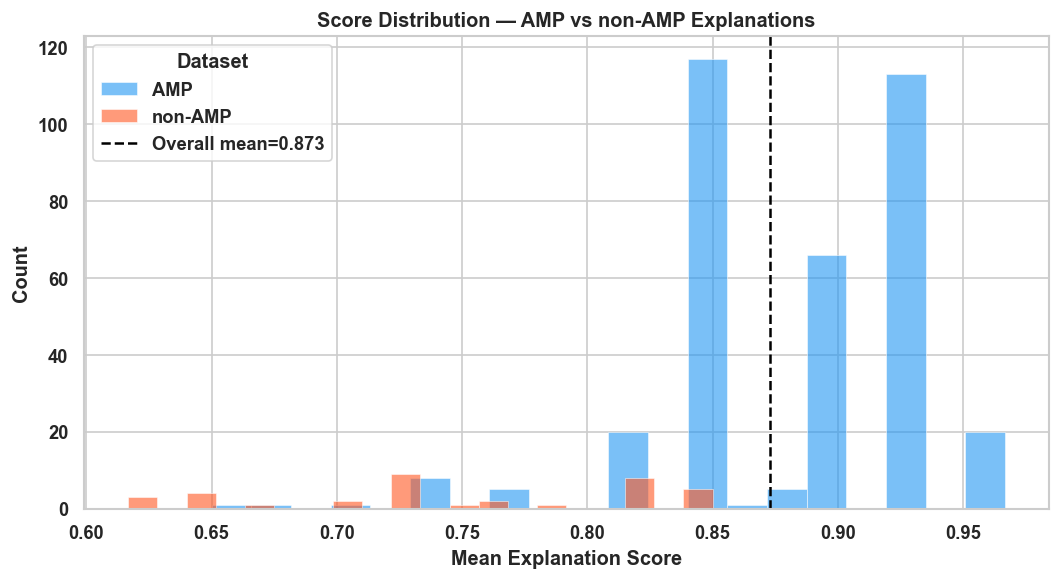

Saved: 01_score_histogram.pdf


In [17]:
# ── Plot 01: Score Distribution Histogram ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colors = {"AMP": "#2196F3", "non-AMP": "#FF5722"}
for label, grp in df_r.groupby("dataset"):
    ax.hist(grp["mean_score"], bins=20, alpha=0.6, label=label,
            color=colors[label], edgecolor="white", linewidth=0.5)

ax.set_title("Score Distribution — AMP vs non-AMP Explanations")
ax.set_xlabel("Mean Explanation Score")
ax.set_ylabel("Count")
ax.legend(title="Dataset")
ax.axvline(df_r["mean_score"].mean(), color="black", linestyle="--",
           linewidth=1.5, label=f"Overall mean={df_r['mean_score'].mean():.3f}")
ax.legend(title="Dataset")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_score_histogram.pdf", bbox_inches="tight")
plt.show()
print("Saved: 01_score_histogram.pdf")


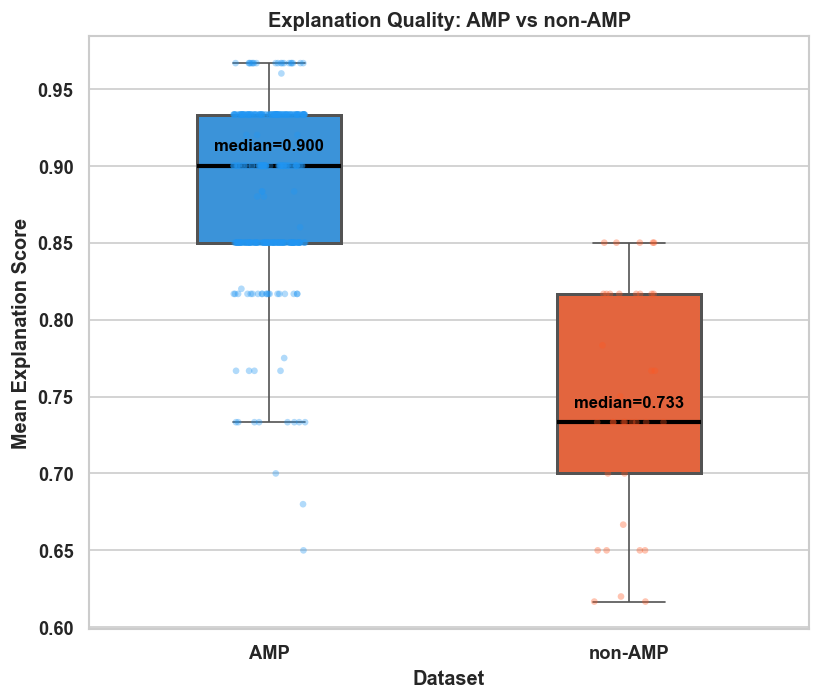

Saved: 02_score_boxplot_dataset.pdf


In [18]:
# ── Plot 02: Box + Strip by Dataset ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

order = ["AMP", "non-AMP"]
palette = {"AMP": "#2196F3", "non-AMP": "#FF5722"}

sns.boxplot(data=df_r, x="dataset", y="mean_score", order=order,
            palette=palette, width=0.4, fliersize=0, ax=ax,
            boxprops=dict(linewidth=1.8), medianprops=dict(color="black", linewidth=2.5))
sns.stripplot(data=df_r, x="dataset", y="mean_score", order=order,
              palette=palette, alpha=0.35, size=4, jitter=True, ax=ax)

ax.set_title("Explanation Quality: AMP vs non-AMP")
ax.set_xlabel("Dataset")
ax.set_ylabel("Mean Explanation Score")

# Annotate medians
for i, ds in enumerate(order):
    med = df_r[df_r["dataset"] == ds]["mean_score"].median()
    ax.text(i, med + 0.01, f"median={med:.3f}", ha="center", fontsize=10,
            fontweight="bold", color="black")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_score_boxplot_dataset.pdf", bbox_inches="tight")
plt.show()
print("Saved: 02_score_boxplot_dataset.pdf")


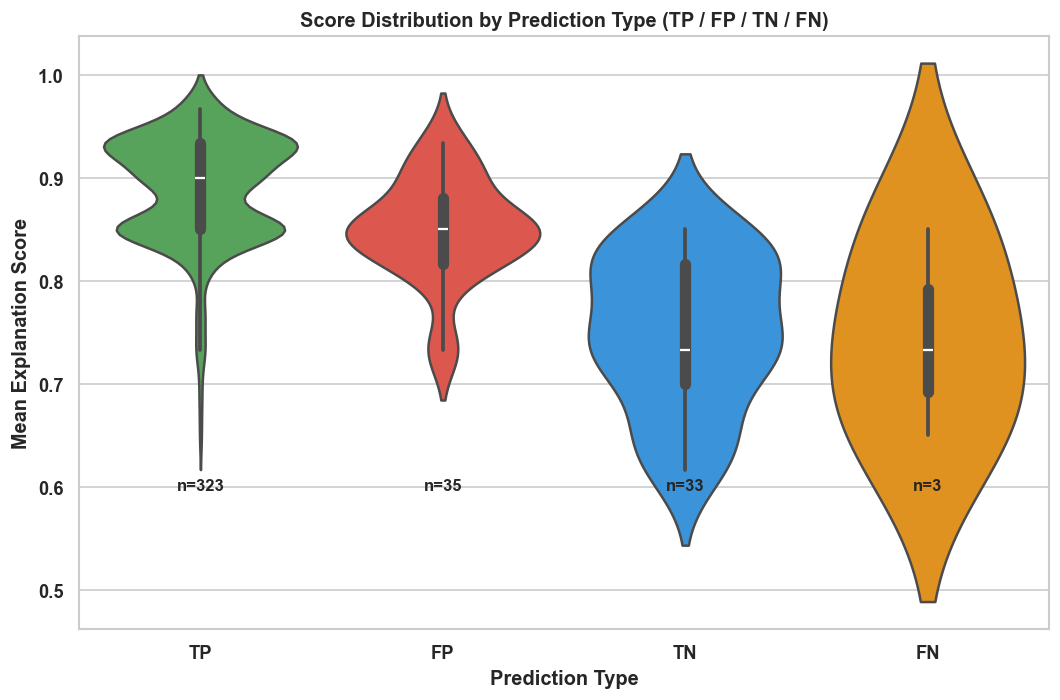

Saved: 03_score_violin_prediction_type.pdf


In [19]:
# ── Plot 03: Violin by Prediction Type ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

type_order  = ["TP", "FP", "TN", "FN"]
type_colors = {"TP": "#4CAF50", "FP": "#F44336", "TN": "#2196F3", "FN": "#FF9800"}

df_plot = df_r[df_r["prediction_result"].isin(type_order)]

sns.violinplot(data=df_plot, x="prediction_result", y="mean_score",
               order=type_order, palette=type_colors,
               inner="box", linewidth=1.5, ax=ax)

ax.set_title("Score Distribution by Prediction Type (TP / FP / TN / FN)")
ax.set_xlabel("Prediction Type")
ax.set_ylabel("Mean Explanation Score")

counts = df_plot["prediction_result"].value_counts()
for i, pt in enumerate(type_order):
    n = counts.get(pt, 0)
    ax.text(i, df_r["mean_score"].min() - 0.02, f"n={n}", ha="center",
            fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_score_violin_prediction_type.pdf", bbox_inches="tight")
plt.show()
print("Saved: 03_score_violin_prediction_type.pdf")


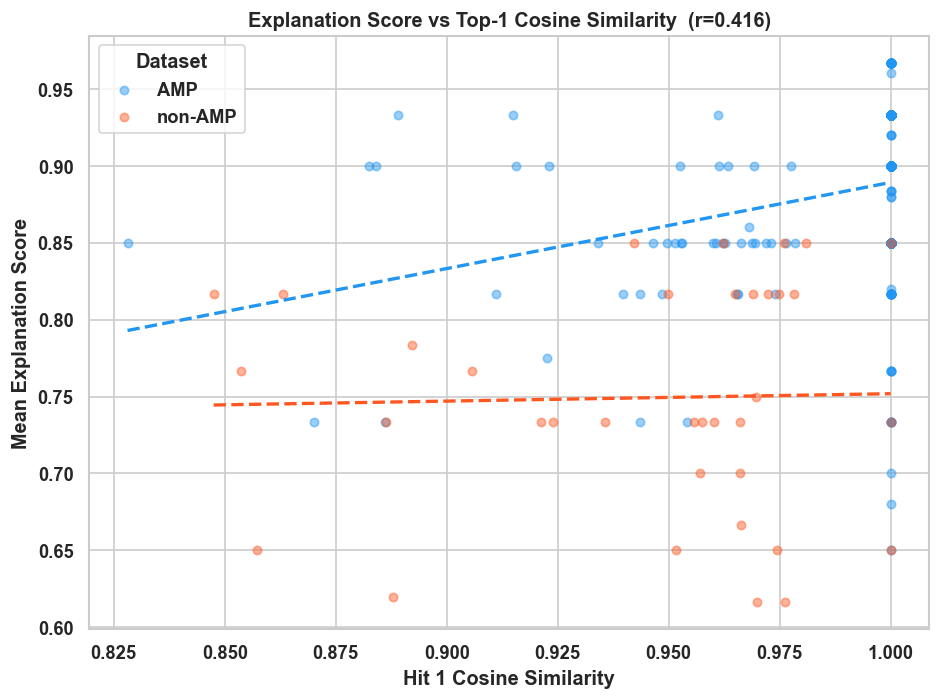

Saved: 04_score_vs_cosine_sim.pdf


In [20]:
# ── Plot 04: Score vs Cosine Similarity (Hit 1) ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

palette = {"AMP": "#2196F3", "non-AMP": "#FF5722"}
for label, grp in df_r.groupby("dataset"):
    ax.scatter(grp["hit1_cosine_sim"], grp["mean_score"],
               alpha=0.45, s=25, label=label, color=palette[label])
    # Regression line
    m, b = np.polyfit(grp["hit1_cosine_sim"], grp["mean_score"], 1)
    xs = np.linspace(grp["hit1_cosine_sim"].min(), grp["hit1_cosine_sim"].max(), 100)
    ax.plot(xs, m*xs + b, linewidth=2, color=palette[label], linestyle="--")

corr = df_r[["hit1_cosine_sim","mean_score"]].corr().iloc[0,1]
ax.set_title(f"Explanation Score vs Top-1 Cosine Similarity  (r={corr:.3f})")
ax.set_xlabel("Hit 1 Cosine Similarity")
ax.set_ylabel("Mean Explanation Score")
ax.legend(title="Dataset")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_score_vs_cosine_sim.pdf", bbox_inches="tight")
plt.show()
print("Saved: 04_score_vs_cosine_sim.pdf")


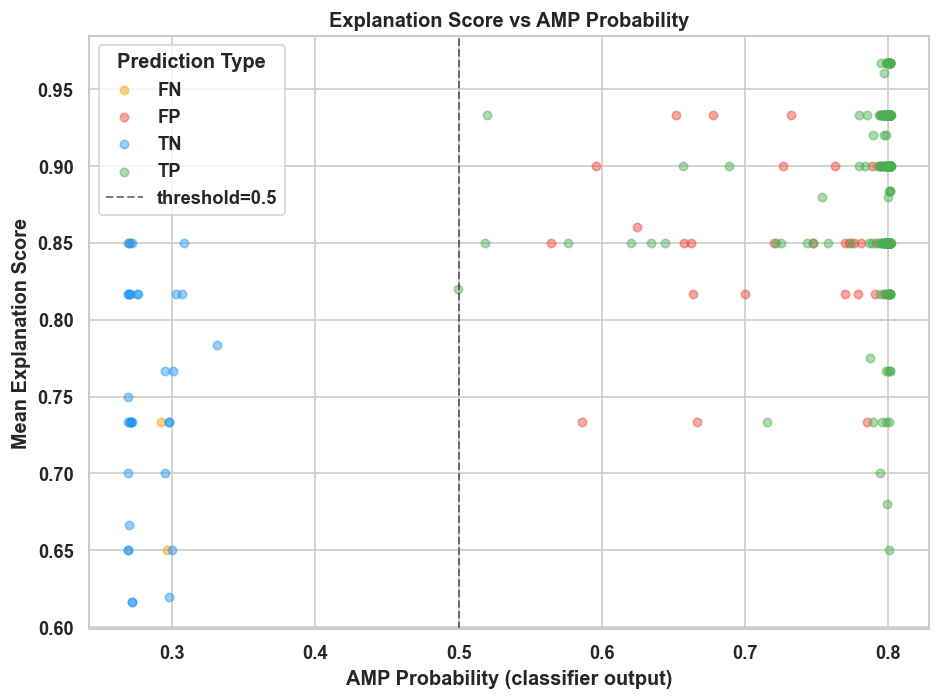

Saved: 05_score_vs_prob_amp.pdf


In [21]:
# ── Plot 05: Score vs AMP Probability ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

type_colors = {"TP": "#4CAF50", "FP": "#F44336", "TN": "#2196F3", "FN": "#FF9800"}
for pt, grp in df_r.groupby("prediction_result"):
    ax.scatter(grp["prob_amp"], grp["mean_score"],
               alpha=0.45, s=25, label=pt, color=type_colors.get(pt, "grey"))

ax.set_title("Explanation Score vs AMP Probability")
ax.set_xlabel("AMP Probability (classifier output)")
ax.set_ylabel("Mean Explanation Score")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, alpha=0.5, label="threshold=0.5")
ax.legend(title="Prediction Type")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_score_vs_prob_amp.pdf", bbox_inches="tight")
plt.show()
print("Saved: 05_score_vs_prob_amp.pdf")


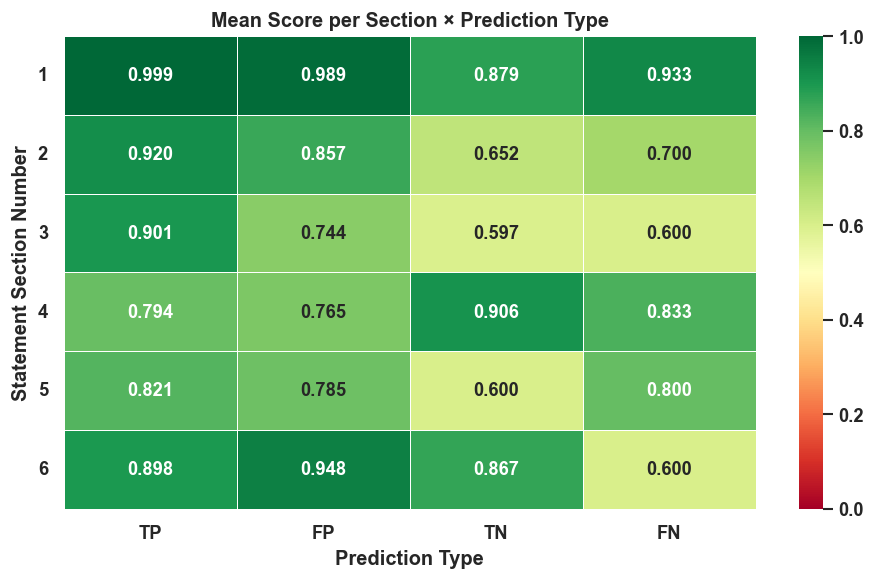

Saved: 06_section_score_heatmap.pdf


In [22]:
# ── Plot 06: Section Score Heatmap ────────────────────────────────────────────
# Expand statement_scores_json to get per-section scores
records = []
for _, row in df_r.iterrows():
    try:
        stmts = json.loads(row["statement_scores_json"])
        if not isinstance(stmts, list): continue
        for s in stmts:
            if "score" in s and "num" in s:
                records.append({
                    "prediction_result": row["prediction_result"],
                    "section_num":       s["num"],
                    "score":             s["score"],
                })
    except Exception:
        pass

df_sect = pd.DataFrame(records)

if not df_sect.empty:
    pivot = df_sect.pivot_table(
        index="section_num", columns="prediction_result",
        values="score", aggfunc="mean"
    )
    # Keep only columns that exist
    cols_order = [c for c in ["TP","FP","TN","FN"] if c in pivot.columns]
    pivot = pivot[cols_order]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",
                linewidths=0.5, linecolor="white", ax=ax,
                vmin=0.0, vmax=1.0,
                annot_kws={"fontsize": 11, "fontweight": "bold"})
    ax.set_title("Mean Score per Section × Prediction Type")
    ax.set_xlabel("Prediction Type")
    ax.set_ylabel("Statement Section Number")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "06_section_score_heatmap.pdf", bbox_inches="tight")
    plt.show()
    print("Saved: 06_section_score_heatmap.pdf")
else:
    print("Not enough statement data to build heatmap (need full JSON parse)")


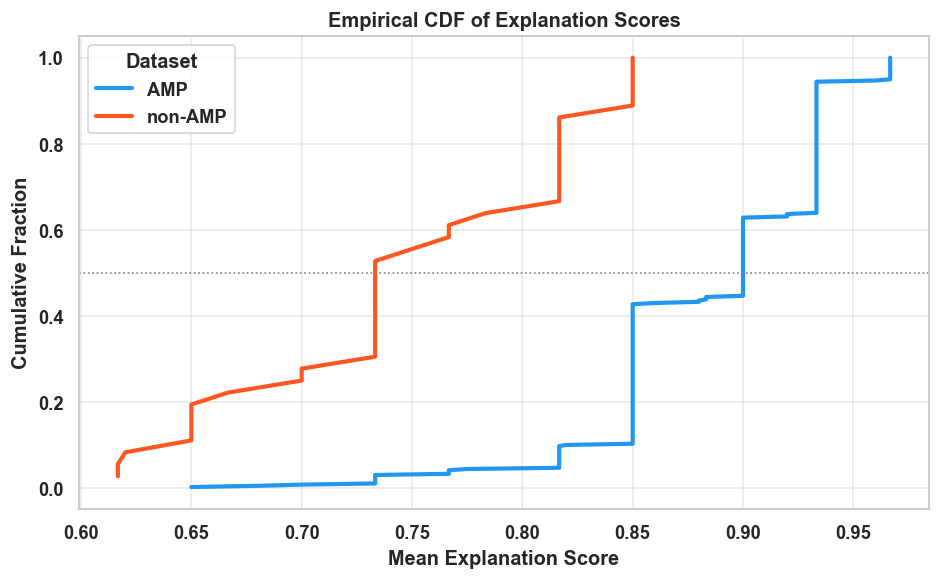

Saved: 07_score_cdf.pdf


In [23]:
# ── Plot 07: Empirical CDF ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

palette = {"AMP": "#2196F3", "non-AMP": "#FF5722"}
for label, grp in df_r.groupby("dataset"):
    scores = np.sort(grp["mean_score"].values)
    cdf    = np.arange(1, len(scores)+1) / len(scores)
    ax.plot(scores, cdf, linewidth=2.5, label=label, color=palette[label])

ax.axhline(0.5, color="grey", linestyle=":", linewidth=1)
ax.set_title("Empirical CDF of Explanation Scores")
ax.set_xlabel("Mean Explanation Score")
ax.set_ylabel("Cumulative Fraction")
ax.legend(title="Dataset")
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_score_cdf.pdf", bbox_inches="tight")
plt.show()
print("Saved: 07_score_cdf.pdf")


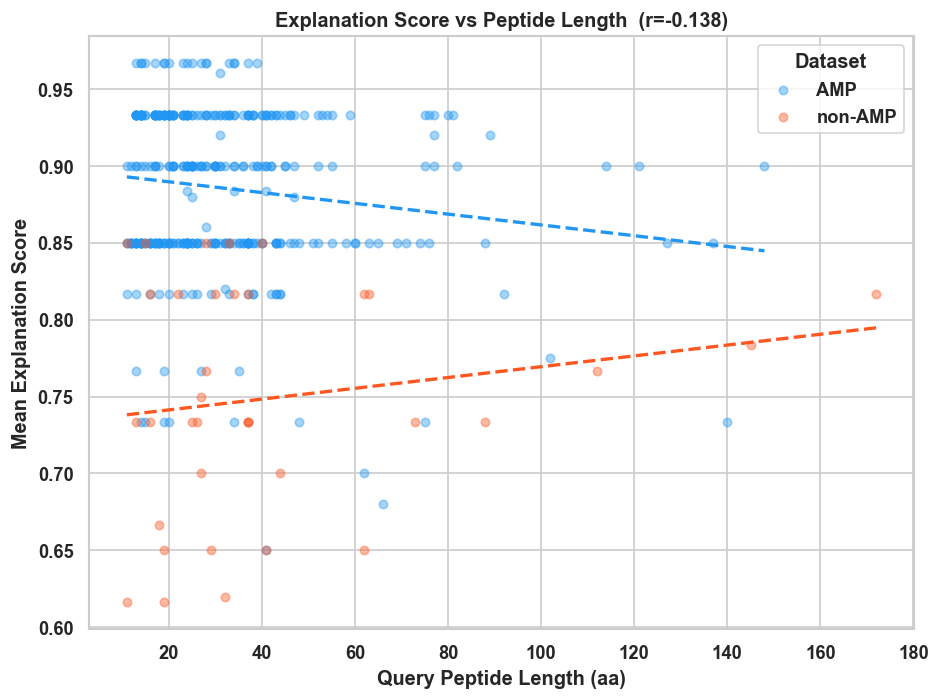

Saved: 08_score_vs_peptide_length.pdf


In [24]:
# ── Plot 08: Score vs Peptide Length ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

palette = {"AMP": "#2196F3", "non-AMP": "#FF5722"}
for label, grp in df_r.groupby("dataset"):
    ax.scatter(grp["query_length"], grp["mean_score"],
               alpha=0.4, s=25, label=label, color=palette[label])
    m, b = np.polyfit(grp["query_length"], grp["mean_score"], 1)
    xs = np.linspace(grp["query_length"].min(), grp["query_length"].max(), 100)
    ax.plot(xs, m*xs + b, linewidth=2, color=palette[label], linestyle="--")

corr = df_r[["query_length","mean_score"]].corr().iloc[0,1]
ax.set_title(f"Explanation Score vs Peptide Length  (r={corr:.3f})")
ax.set_xlabel("Query Peptide Length (aa)")
ax.set_ylabel("Mean Explanation Score")
ax.legend(title="Dataset")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_score_vs_peptide_length.pdf", bbox_inches="tight")
plt.show()
print("Saved: 08_score_vs_peptide_length.pdf")


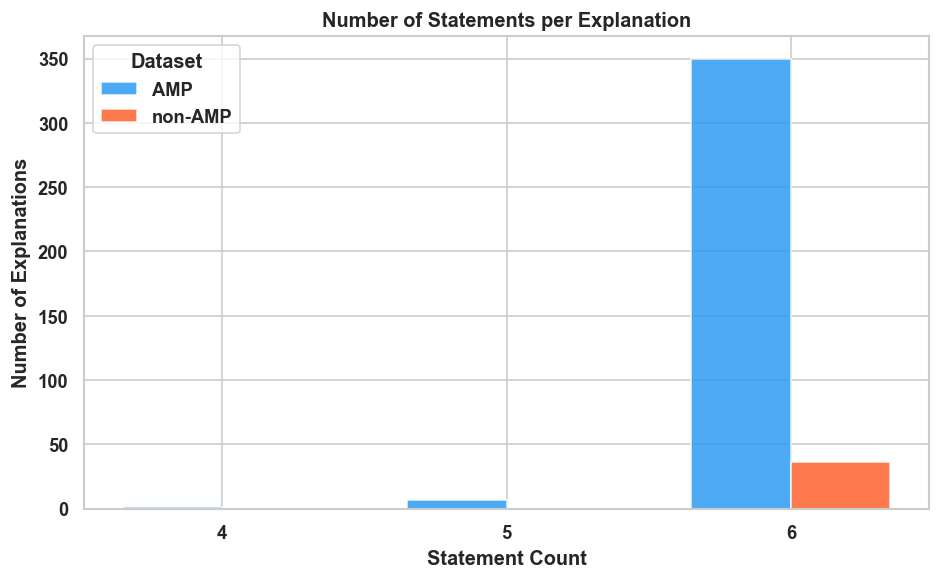

Saved: 09_num_statements_bar.pdf


In [25]:
# ── Plot 09: Number of Statements Distribution ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

palette = {"AMP": "#2196F3", "non-AMP": "#FF5722"}
counts = df_r.groupby(["dataset","num_statements"]).size().reset_index(name="count")
datasets = counts["dataset"].unique()
x_vals   = sorted(counts["num_statements"].unique())
width    = 0.35
x        = np.arange(len(x_vals))

for i, ds in enumerate(["AMP","non-AMP"]):
    sub = counts[counts["dataset"] == ds]
    sub = sub.set_index("num_statements").reindex(x_vals, fill_value=0)
    ax.bar(x + (i - 0.5) * width, sub["count"].values, width=width,
           label=ds, color=palette[ds], alpha=0.8, edgecolor="white")

ax.set_title("Number of Statements per Explanation")
ax.set_xlabel("Statement Count")
ax.set_ylabel("Number of Explanations")
ax.set_xticks(x)
ax.set_xticklabels(x_vals)
ax.legend(title="Dataset")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_num_statements_bar.pdf", bbox_inches="tight")
plt.show()
print("Saved: 09_num_statements_bar.pdf")


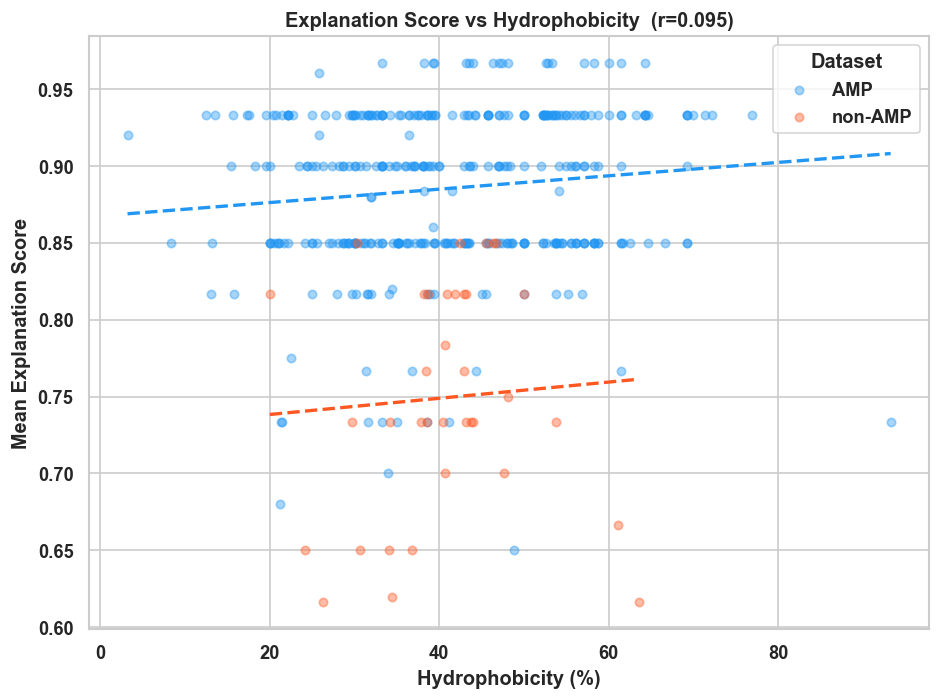

Saved: 10_score_vs_hydrophobicity.pdf


In [26]:
# ── Plot 10: Score vs Hydrophobicity ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

palette = {"AMP": "#2196F3", "non-AMP": "#FF5722"}
for label, grp in df_r.groupby("dataset"):
    ax.scatter(grp["hydrophobicity_pct"], grp["mean_score"],
               alpha=0.4, s=25, label=label, color=palette[label])
    m, b = np.polyfit(grp["hydrophobicity_pct"], grp["mean_score"], 1)
    xs = np.linspace(grp["hydrophobicity_pct"].min(), grp["hydrophobicity_pct"].max(), 100)
    ax.plot(xs, m*xs + b, linewidth=2, color=palette[label], linestyle="--")

corr = df_r[["hydrophobicity_pct","mean_score"]].corr().iloc[0,1]
ax.set_title(f"Explanation Score vs Hydrophobicity  (r={corr:.3f})")
ax.set_xlabel("Hydrophobicity (%)")
ax.set_ylabel("Mean Explanation Score")
ax.legend(title="Dataset")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "10_score_vs_hydrophobicity.pdf", bbox_inches="tight")
plt.show()
print("Saved: 10_score_vs_hydrophobicity.pdf")


Unique activities found: 44
item
Anti-Gram positive    939
Antibacterial         925
Antimicrobial         890
Anti-Gram negative    888
Antifungal            717
Antiviral             394
Toxic to mammals      394
Toxic                 182
Hemolytic             142
Anticancer            100
Name: count, dtype: int64


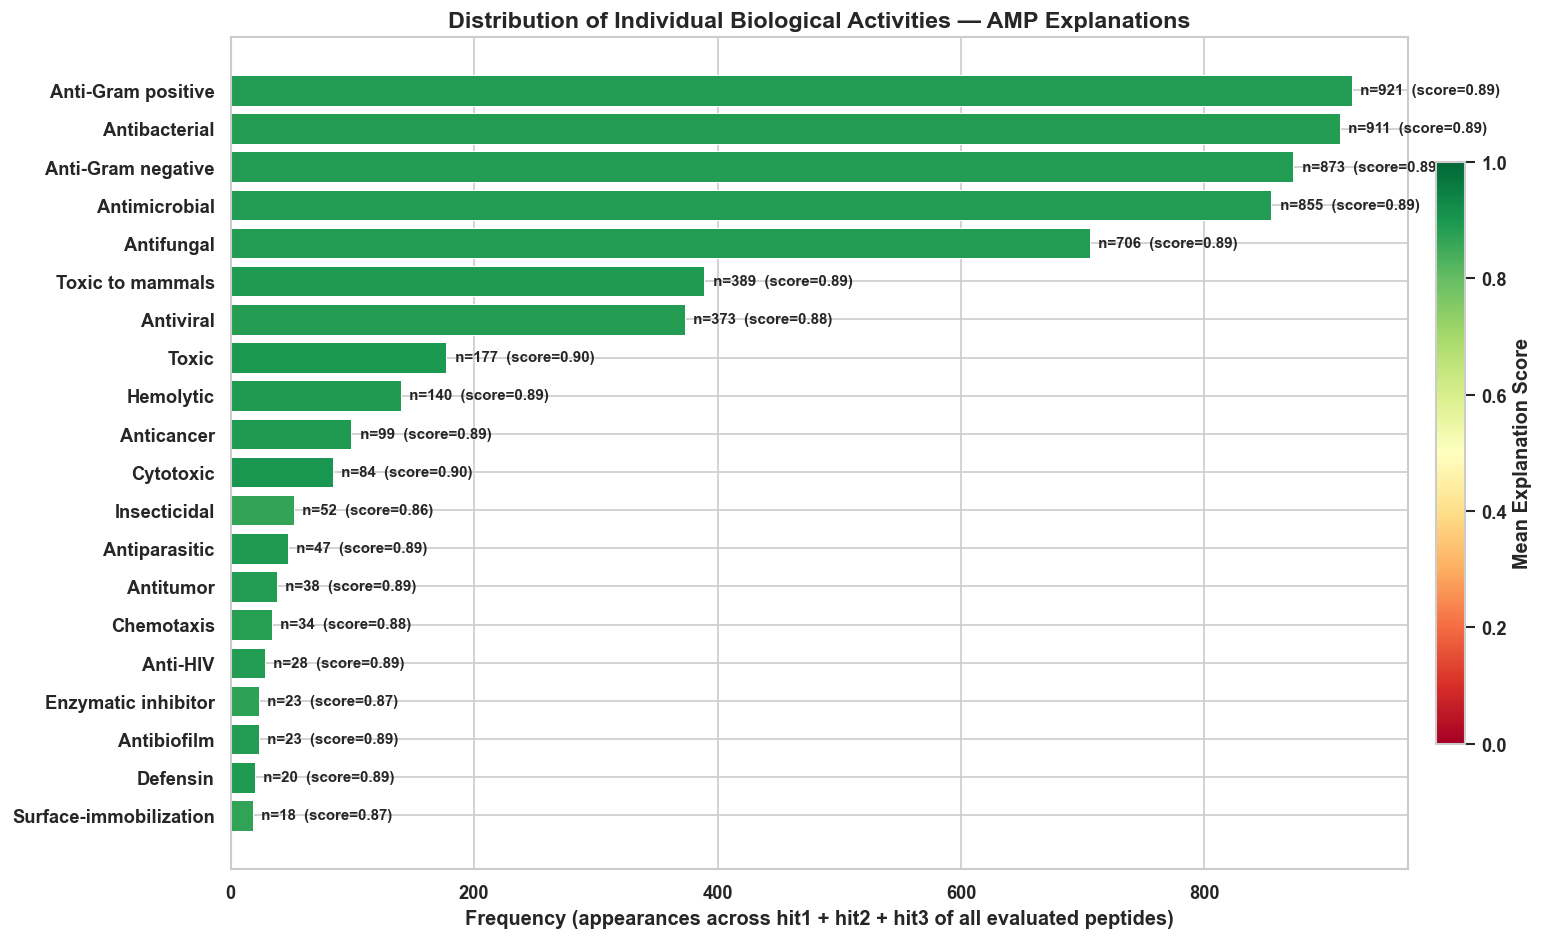

Saved: 11_amp_activity_distribution.pdf


In [27]:
# ── Shared helper: merge eval results with original hit columns ────────────
df_amp_src = pd.read_csv(AMP_CSV).assign(dataset="AMP")
df_non_src = pd.read_csv(NON_AMP_CSV).assign(dataset="non-AMP")

# For non-AMP UniProt data, map keywords → activities, organism → targets
df_non_mapped = df_non_src[["seq_idx", "dataset"]].copy()
for n in [1, 2, 3]:
    df_non_mapped[f"hit{n}_activities"] = df_non_src.get(f"hit{n}_keywords", pd.Series(dtype=str))
    df_non_mapped[f"hit{n}_targets"]    = df_non_src.get(f"hit{n}_organism", pd.Series(dtype=str))

activity_cols = ["seq_idx", "dataset",
                 "hit1_activities", "hit2_activities", "hit3_activities",
                 "hit1_targets",    "hit2_targets",    "hit3_targets"]

df_src = pd.concat([
    df_amp_src[activity_cols],
    df_non_mapped[activity_cols],
], ignore_index=True)

df_merged = df_r.merge(df_src, on=["seq_idx", "dataset"], how="left")


def explode_csv(df, cols, value_col="mean_score"):
    """
    Explode comma-separated values in `cols` into individual rows.
    Each unique activity / organism gets its own row with the peptide's mean_score.
    Count = how many times that item appeared across hit1+hit2+hit3 of all peptides.
    """
    records = []
    for _, row in df.iterrows():
        for col in cols:
            val = row.get(col, "")
            if not isinstance(val, str):
                continue
            for item in val.split(","):
                item = item.strip()
                if item:
                    records.append({
                        "item":      item,
                        value_col:   row[value_col],
                        "dataset":   row["dataset"],
                    })
    return pd.DataFrame(records)


def single_bar_plot(df_long, dataset, title, xlabel, filename):
    """
    One horizontal bar per individual activity / organism.
    Bar length = frequency; bar colour = mean explanation score (RdYlGn).
    """
    sub = df_long[df_long["dataset"] == dataset]
    if sub.empty:
        print(f"No data for {dataset}")
        return
    counts  = sub["item"].value_counts().head(20)
    mean_sc = sub.groupby("item")["mean_score"].mean().reindex(counts.index)
    norm    = plt.Normalize(vmin=0.0, vmax=1.0)
    cmap    = plt.get_cmap("RdYlGn")
    colors  = [cmap(norm(v)) for v in mean_sc.values]

    fig, ax = plt.subplots(figsize=(14, 8))
    y_pos = range(len(counts))
    bars  = ax.barh(list(y_pos), counts.values, color=colors,
                    edgecolor="white", linewidth=0.6)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(counts.index, fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold")

    for bar, cnt, sc in zip(bars, counts.values, mean_sc.values):
        ax.text(cnt + 0.3, bar.get_y() + bar.get_height() / 2,
                f"  n={cnt}  (score={sc:.2f})", va="center",
                fontsize=9, fontweight="bold")

    sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Mean Explanation Score", shrink=0.7, pad=0.02)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")


# ── Build activity long-form (one row per individual activity per hit) ────
# Activities in CSV are comma-separated: "Antimicrobial, Antibacterial, Anti-Gram positive"
# Each activity gets its own bar; count = appearances across all 3 hits of all peptides
df_acts = explode_csv(df_merged,
                      ["hit1_activities", "hit2_activities", "hit3_activities"])

print(f"Unique activities found: {df_acts['item'].nunique()}")
print(df_acts["item"].value_counts().head(10))

# ── Plot 11: AMP biological activities ───────────────────────────────────
single_bar_plot(
    df_acts, "AMP",
    title="Distribution of Individual Biological Activities — AMP Explanations",
    xlabel="Frequency (appearances across hit1 + hit2 + hit3 of all evaluated peptides)",
    filename="11_amp_activity_distribution.pdf",
)


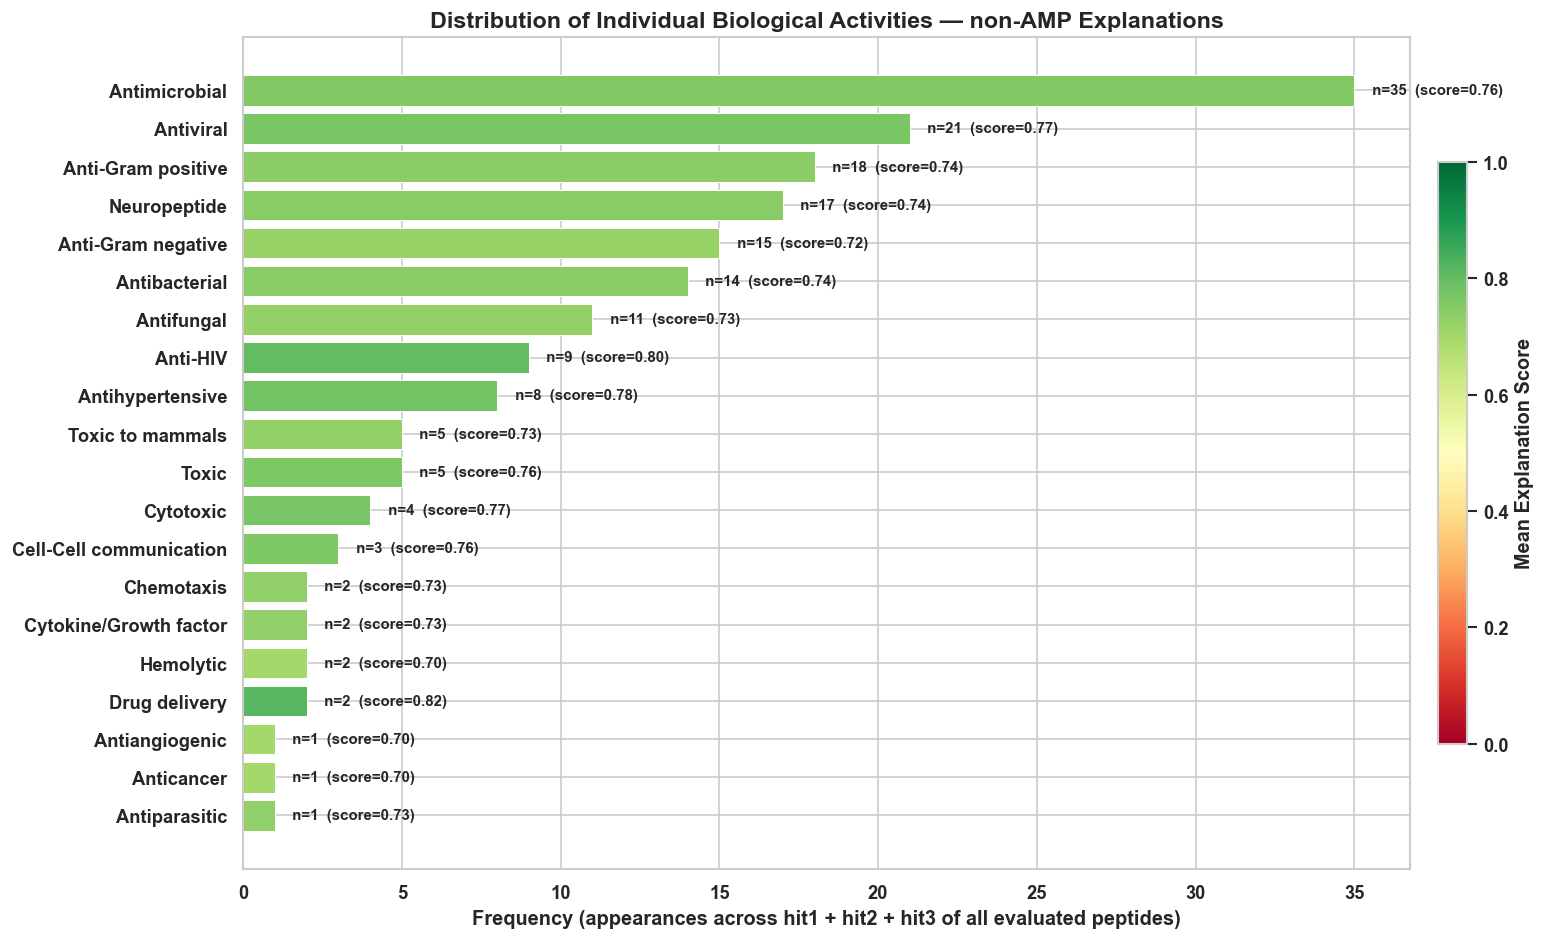

Saved: 12_noamp_activity_distribution.pdf


In [28]:
# ── Plot 12: non-AMP biological activities ───────────────────────────────
single_bar_plot(
    df_acts, "non-AMP",
    title="Distribution of Individual Biological Activities — non-AMP Explanations",
    xlabel="Frequency (appearances across hit1 + hit2 + hit3 of all evaluated peptides)",
    filename="12_noamp_activity_distribution.pdf",
)


Unique target organisms found: 392
item
Escherichia coli              718
Staphylococcus aureus         673
Candida albicans              418
Pseudomonas aeruginosa        339
Human erythrocytes            268
Bacillus subtilis             211
Klebsiella pneumoniae         160
Enterococcus faecalis         146
Micrococcus luteus            136
Staphylococcus epidermidis    109
Name: count, dtype: int64


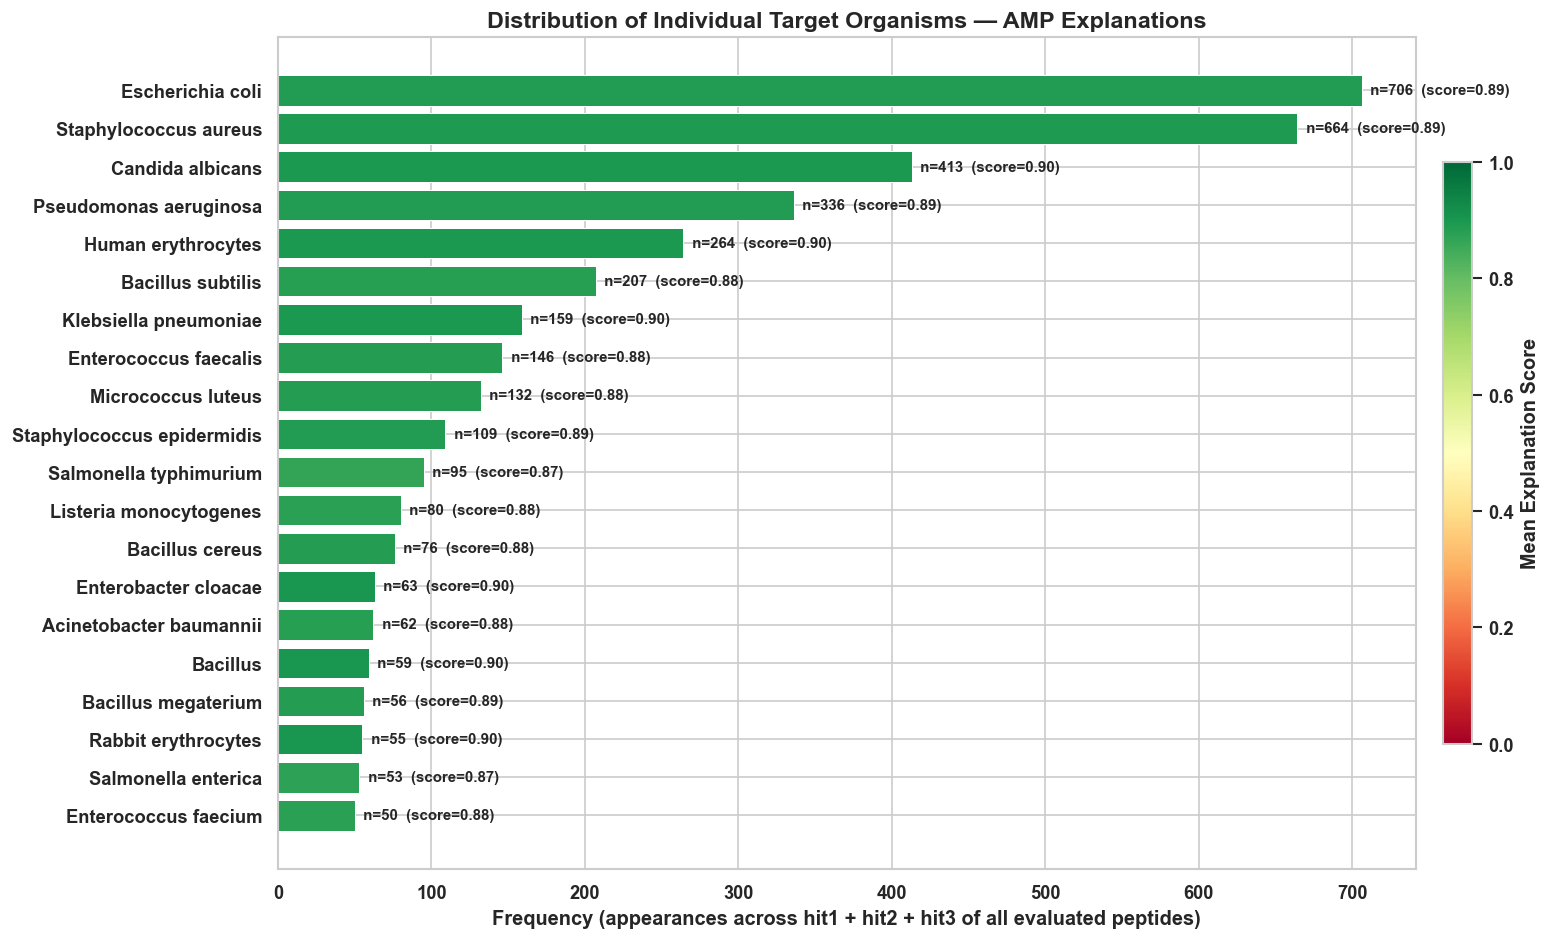

Saved: 13_amp_target_distribution.pdf


In [29]:
# ── Build target organism long-form (one row per individual organism per hit) ─
# Targets in CSV are comma-separated: "Staphylococcus aureus, Escherichia coli, ..."
# Each organism gets its own bar
df_tgts = explode_csv(df_merged,
                      ["hit1_targets", "hit2_targets", "hit3_targets"])

print(f"Unique target organisms found: {df_tgts['item'].nunique()}")
print(df_tgts["item"].value_counts().head(10))

# ── Plot 13: AMP target organisms ────────────────────────────────────────
single_bar_plot(
    df_tgts, "AMP",
    title="Distribution of Individual Target Organisms — AMP Explanations",
    xlabel="Frequency (appearances across hit1 + hit2 + hit3 of all evaluated peptides)",
    filename="13_amp_target_distribution.pdf",
)


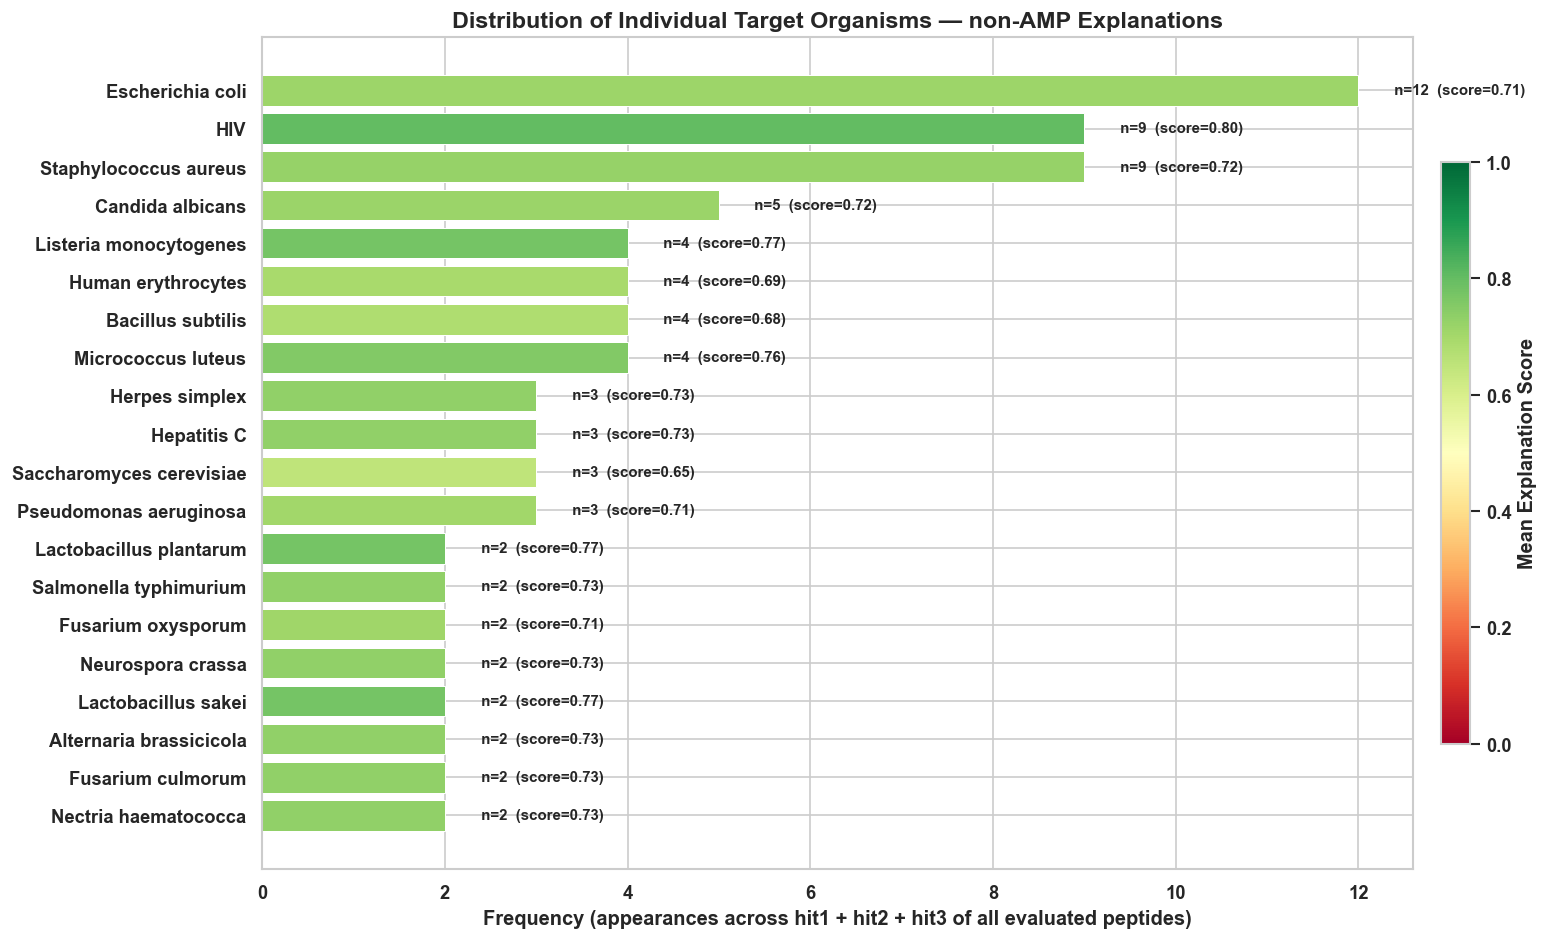

Saved: 14_noamp_target_distribution.pdf


In [30]:
# ── Plot 14: non-AMP target organisms ────────────────────────────────────
single_bar_plot(
    df_tgts, "non-AMP",
    title="Distribution of Individual Target Organisms — non-AMP Explanations",
    xlabel="Frequency (appearances across hit1 + hit2 + hit3 of all evaluated peptides)",
    filename="14_noamp_target_distribution.pdf",
)


## 13. Running with Different Judge Models

To compare evaluation results across models:

1. Change `JUDGE_BACKEND` and `JUDGE_MODEL` in **Cell 2**
2. Delete or rename the existing `bio_eval_results.csv` to avoid resuming old results
3. Re-run from **Cell 2** onwards
4. The `judge_model` column in the output CSV records which model was used

### Model comparison table (fill in after running)

| Judge Model | Backend | Mean AMP Score | Mean non-AMP Score | Parse Errors |
|-------------|---------|---------------|-------------------|--------------|
| llama3.1:8b | ollama | | | |
| qwen2.5:7b | ollama | | | |
| gemma2:9b | ollama | | | |
| claude-haiku-4-5 | anthropic | | | |
| claude-sonnet-4-6 | anthropic | | | |

> **Note on judge selection**: Local 8B models tend to give inflated scores with narrow variance. Larger models (claude-haiku-4-5, claude-sonnet-4-6) produce more discriminative scoring, especially for specialized biological claims.
